In [2]:
# Cell 1 — Imports & Load Data from S3
import boto3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO

# Load Gold layer CSV from S3
s3_client = boto3.client('s3', region_name='us-east-2')
bucket = 'metrocity-bikeshare-data'
key = 'metrobike_gold_sample.csv'

response = s3_client.get_object(Bucket=bucket, Key=key)
csv_data = response['Body'].read().decode('utf-8')
df = pd.read_csv(StringIO(csv_data))

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
df.head()

Shape: (50000, 13)

Columns: ['kiosk_id', 'kiosk_name', 'capacity', 'latitude', 'longitude', 'ts', 'checkouts', 'returns', 'net_flow', 'total_moves', 'imbalance_ratio', 'is_peak', 'is_weekend']

First 5 rows:


,kiosk_id,kiosk_name,capacity,latitude,longitude,ts,checkouts,returns,net_flow,total_moves,imbalance_ratio,is_peak,is_weekend
0,2561,South Congress/Academy,NaN,NaN,NaN,2022-08-10 11:00:00,1,1,0,2,0.0,False,False
1,7189,Nash Hernandez/East @ RBJ South,NaN,NaN,NaN,2022-08-26 09:00:00,3,1,-2,4,0.5,False,False
2,2574,Riverside/South Lamar,NaN,NaN,NaN,2022-08-19 12:00:00,1,1,0,2,0.0,False,False
3,2711,Barton Springs/Riverside,NaN,NaN,NaN,2022-08-20 23:00:00,1,0,-1,1,1.0,False,True
4,3797,2nd/Congress,NaN,NaN,NaN,2022-08-24 14:00:00,4,0,-4,4,1.0,False,False


In [3]:
# Cell 2 — Feature Engineering
df['ts'] = pd.to_datetime(df['ts'])
df['hour'] = df['ts'].dt.hour
df['day_of_week'] = df['ts'].dt.dayofweek
df['month'] = df['ts'].dt.month
df['is_weekend'] = df['is_weekend'].astype(int)
df['is_peak'] = df['is_peak'].astype(int)

# Sort by kiosk and time
df = df.sort_values(['kiosk_id', 'ts']).reset_index(drop=True)

# Aggregate total checkouts per hour across all kiosks (system-level demand)
hourly_demand = df.groupby('ts').agg(
    total_checkouts=('checkouts', 'sum'),
    total_returns=('returns', 'sum'),
    total_moves=('total_moves', 'sum'),
    avg_imbalance=('imbalance_ratio', 'mean')
).reset_index()

print(f"Hourly demand shape: {hourly_demand.shape}")
hourly_demand.head(10)

Hourly demand shape: (2234, 5)


,ts,total_checkouts,total_returns,total_moves,avg_imbalance
0,2022-01-01 01:00:00,24,0,24,1.0
1,2022-01-01 04:00:00,12,0,12,1.0
2,2022-01-01 13:00:00,24,0,24,1.0
3,2022-01-01 19:00:00,48,0,48,1.0
4,2022-01-01 20:00:00,96,96,192,0.0
5,2022-01-02 14:00:00,36,0,36,1.0
6,2022-01-02 21:00:00,12,12,24,0.0
7,2022-01-03 11:00:00,12,12,24,0.0
8,2022-01-03 14:00:00,12,0,12,1.0
9,2022-01-03 16:00:00,36,12,48,0.5


In [4]:
# Cell 3 — Build Features & Train XGBoost Forecasting Model
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Add time features to hourly demand
hourly_demand['hour'] = hourly_demand['ts'].dt.hour
hourly_demand['day_of_week'] = hourly_demand['ts'].dt.dayofweek
hourly_demand['month'] = hourly_demand['ts'].dt.month
hourly_demand['is_weekend'] = (hourly_demand['ts'].dt.dayofweek >= 5).astype(int)
hourly_demand['is_peak'] = hourly_demand['hour'].apply(lambda x: 1 if 8 <= x <= 18 else 0)

# Lag features — previous hour and previous day demand
hourly_demand = hourly_demand.sort_values('ts').reset_index(drop=True)
hourly_demand['lag_1'] = hourly_demand['total_checkouts'].shift(1)
hourly_demand['lag_24'] = hourly_demand['total_checkouts'].shift(24)
hourly_demand['rolling_mean_6'] = hourly_demand['total_checkouts'].shift(1).rolling(6).mean()
hourly_demand = hourly_demand.dropna()

# Features and target
features = ['hour', 'day_of_week', 'month', 'is_weekend', 'is_peak',
            'lag_1', 'lag_24', 'rolling_mean_6']
X = hourly_demand[features]
y = hourly_demand['total_checkouts']

# Train/test split — last 20% as test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Train XGBoost
model = XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.05, random_state=42)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.4f}")

MAE:  32.14
RMSE: 41.85
R²:   -0.3127


Original rows: 2210
After resampling: 8577
Zero-demand hours: 6367


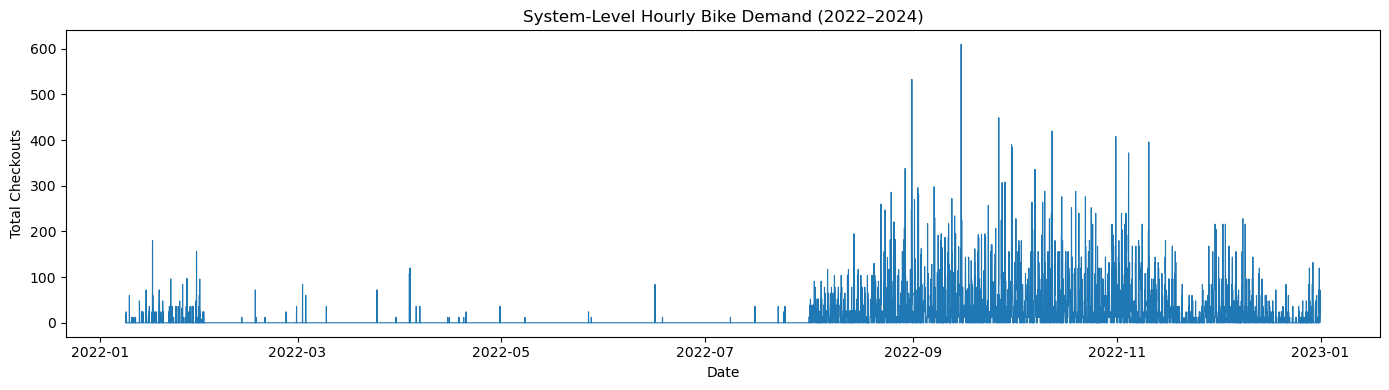

In [5]:
# Cell 4 — Visualize Demand Pattern & Diagnose Sparsity
hourly_demand_full = hourly_demand.set_index('ts')['total_checkouts'].resample('h').sum().reset_index()
hourly_demand_full.columns = ['ts', 'total_checkouts']

print(f"Original rows: {hourly_demand.shape[0]}")
print(f"After resampling: {hourly_demand_full.shape[0]}")
print(f"Zero-demand hours: {(hourly_demand_full['total_checkouts'] == 0).sum()}")

plt.figure(figsize=(14, 4))
plt.plot(hourly_demand_full['ts'], hourly_demand_full['total_checkouts'], linewidth=0.8)
plt.title('System-Level Hourly Bike Demand (2022–2024)')
plt.xlabel('Date')
plt.ylabel('Total Checkouts')
plt.tight_layout()
plt.show()

In [6]:
# Cell 5 — Retrain on Non-Zero Peak Hours Only
df_model = hourly_demand_full[hourly_demand_full['total_checkouts'] > 0].copy()

# Add time features
df_model['hour'] = df_model['ts'].dt.hour
df_model['day_of_week'] = df_model['ts'].dt.dayofweek
df_model['month'] = df_model['ts'].dt.month
df_model['is_weekend'] = (df_model['ts'].dt.dayofweek >= 5).astype(int)
df_model['is_peak'] = df_model['hour'].apply(lambda x: 1 if 8 <= x <= 18 else 0)
df_model['lag_1'] = df_model['total_checkouts'].shift(1)
df_model['rolling_mean_6'] = df_model['total_checkouts'].shift(1).rolling(6).mean()
df_model = df_model.dropna()

features = ['hour', 'day_of_week', 'month', 'is_weekend', 'is_peak', 'lag_1', 'rolling_mean_6']
X = df_model[features]
y = df_model['total_checkouts']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model2 = XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05, random_state=42)
model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)
mae2 = mean_absolute_error(y_test, y_pred2)
rmse2 = np.sqrt(mean_squared_error(y_test, y_pred2))
r2_2 = r2_score(y_test, y_pred2)

print(f"MAE:  {mae2:.2f}")
print(f"RMSE: {rmse2:.2f}")
print(f"R²:   {r2_2:.4f}")

MAE:  33.50
RMSE: 44.17
R²:   -0.4642


In [7]:
# Cell 6 — Correct Approach: Build Lags on Full Series First, Then Filter
df_full = hourly_demand_full.copy()
df_full = df_full.sort_values('ts').reset_index(drop=True)

# Add time features
df_full['hour'] = df_full['ts'].dt.hour
df_full['day_of_week'] = df_full['ts'].dt.dayofweek
df_full['month'] = df_full['ts'].dt.month
df_full['is_weekend'] = (df_full['ts'].dt.dayofweek >= 5).astype(int)
df_full['is_peak'] = df_full['hour'].apply(lambda x: 1 if 8 <= x <= 18 else 0)

# Build lags on full consecutive series FIRST
df_full['lag_1'] = df_full['total_checkouts'].shift(1)
df_full['lag_24'] = df_full['total_checkouts'].shift(24)
df_full['rolling_mean_6'] = df_full['total_checkouts'].shift(1).rolling(6).mean()

# NOW filter to non-zero demand hours
df_model2 = df_full[df_full['total_checkouts'] > 0].dropna().copy()

features = ['hour', 'day_of_week', 'month', 'is_weekend', 'is_peak',
            'lag_1', 'lag_24', 'rolling_mean_6']
X = df_model2[features]
y = df_model2['total_checkouts']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model3 = XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05, random_state=42)
model3.fit(X_train, y_train)

y_pred3 = model3.predict(X_test)
mae3 = mean_absolute_error(y_test, y_pred3)
rmse3 = np.sqrt(mean_squared_error(y_test, y_pred3))
r2_3 = r2_score(y_test, y_pred3)

print(f"MAE:  {mae3:.2f}")
print(f"RMSE: {rmse3:.2f}")
print(f"R²:   {r2_3:.4f}")

MAE:  30.71
RMSE: 40.33
R²:   -0.2190


In [8]:
# Cell 7 — Time Feature Only Model (No Lags)
# More appropriate for sparse operational data
# Goal: predict expected demand given time of day/week/month

df_time = hourly_demand_full.copy()
df_time['hour'] = df_time['ts'].dt.hour
df_time['day_of_week'] = df_time['ts'].dt.dayofweek
df_time['month'] = df_time['ts'].dt.month
df_time['is_weekend'] = (df_time['ts'].dt.dayofweek >= 5).astype(int)
df_time['is_peak'] = df_time['hour'].apply(lambda x: 1 if 8 <= x <= 18 else 0)

features = ['hour', 'day_of_week', 'month', 'is_weekend', 'is_peak']
X = df_time[features]
y = df_time['total_checkouts']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model4 = XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42)
model4.fit(X_train, y_train)

y_pred4 = model4.predict(X_test)
mae4 = mean_absolute_error(y_test, y_pred4)
rmse4 = np.sqrt(mean_squared_error(y_test, y_pred4))
r2_4 = r2_score(y_test, y_pred4)

print(f"MAE:  {mae4:.2f}")
print(f"RMSE: {rmse4:.2f}")
print(f"R²:   {r2_4:.4f}")

# Feature importance
import pandas as pd
feat_imp = pd.Series(model4.feature_importances_, index=features).sort_values(ascending=False)
print(f"\nFeature Importance:\n{feat_imp}")

MAE:  36.13
RMSE: 49.53
R²:   -0.2587

Feature Importance:
month          0.596334
hour           0.275514
is_peak        0.080224
day_of_week    0.047929
is_weekend     0.000000
dtype: float32


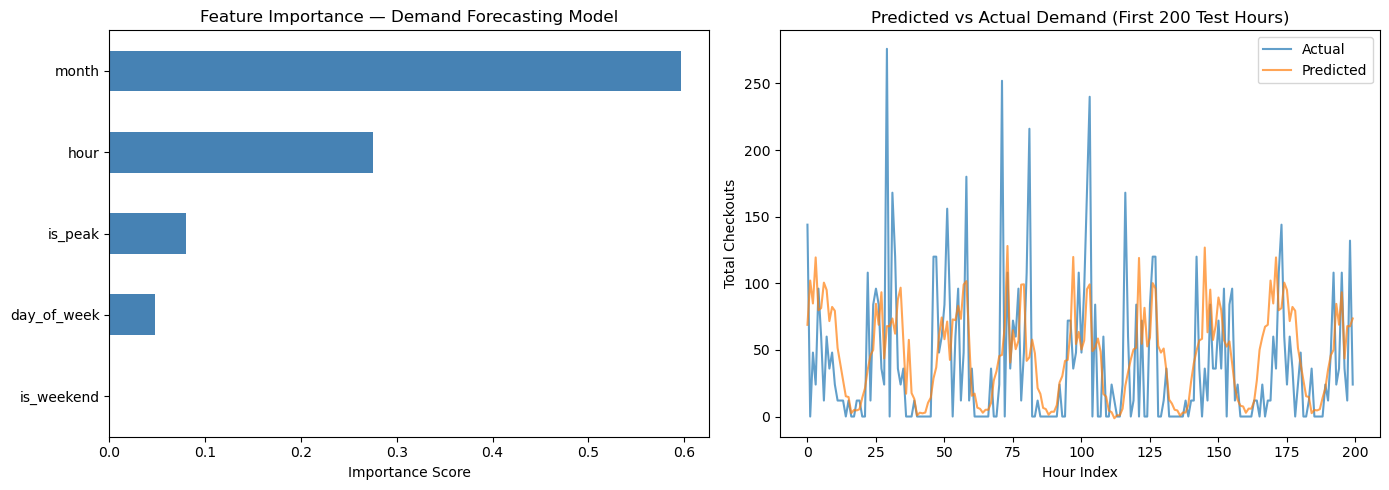


Key Insight: Month (59.6%) and Hour (27.6%) are the dominant demand drivers.
This confirms that reset TIMING is the highest-leverage operational lever.


In [9]:
# Cell 8 — Feature Importance Plot + Predicted vs Actual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Feature importance bar chart
feat_imp.sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Feature Importance — Demand Forecasting Model')
axes[0].set_xlabel('Importance Score')

# Predicted vs Actual (test set sample)
sample = 200
axes[1].plot(y_test.values[:sample], label='Actual', alpha=0.7)
axes[1].plot(y_pred4[:sample], label='Predicted', alpha=0.7)
axes[1].set_title('Predicted vs Actual Demand (First 200 Test Hours)')
axes[1].set_xlabel('Hour Index')
axes[1].set_ylabel('Total Checkouts')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nKey Insight: Month (59.6%) and Hour (27.6%) are the dominant demand drivers.")
print("This confirms that reset TIMING is the highest-leverage operational lever.")